<div align="center">
  <font color="blue" size="6">
    <b><u>Machine Learning Project</u></b> 🤖
  </font>
</div>

**Objective**: Predict Employee Turnover.

**Business Tasks**:

⚙️Perform data quality checks by checking for missing values, if any.

⚙️Understand what factors contributed most to employee turnover at EDA.

⚙️Perform clustering of employees who left based on their satisfaction and evaluation.

⚙️Handle the left Class Imbalance using the SMOTE technique.

⚙️Perform k-fold cross-validation model training and evaluate performance.

⚙️Identify the best model and justify the evaluation metrics used.  

⚙️Suggest various retention strategies for targeted employees.

In [25]:
## Importing necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import KFold, StratifiedKFold, LeaveOneOut
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import confusion_matrix
from sklearn.metrics import  roc_curve, auc
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn import metrics



df= pd.read_csv("HR_comma_sep.csv")


<font color="purple" size="5">
<b>Perform data quality checks by checking for missing values, if any</b>
</font>

In [26]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


In [27]:
## Checking for missing Values
missing_values=df.isnull().sum()
print("Missing Values per Column")
print(missing_values)

Missing Values per Column
satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64


In [28]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


In [29]:
## dropping duplicate
df_no_duplicates = df.drop_duplicates()
print(df_no_duplicates)

       satisfaction_level  last_evaluation  number_project  \
0                    0.38             0.53               2   
1                    0.80             0.86               5   
2                    0.11             0.88               7   
3                    0.72             0.87               5   
4                    0.37             0.52               2   
...                   ...              ...             ...   
11995                0.90             0.55               3   
11996                0.74             0.95               5   
11997                0.85             0.54               3   
11998                0.33             0.65               3   
11999                0.50             0.73               4   

       average_montly_hours  time_spend_company  Work_accident  left  \
0                       157                   3              0     1   
1                       262                   6              0     1   
2                       272            

<font color="purple" size="5">
<b>Understand what factors contributed most to employee turnover at EDA.

</b>
</font>

Draw a heatmap of the correlation matrix between all numerical features or columns in the data.

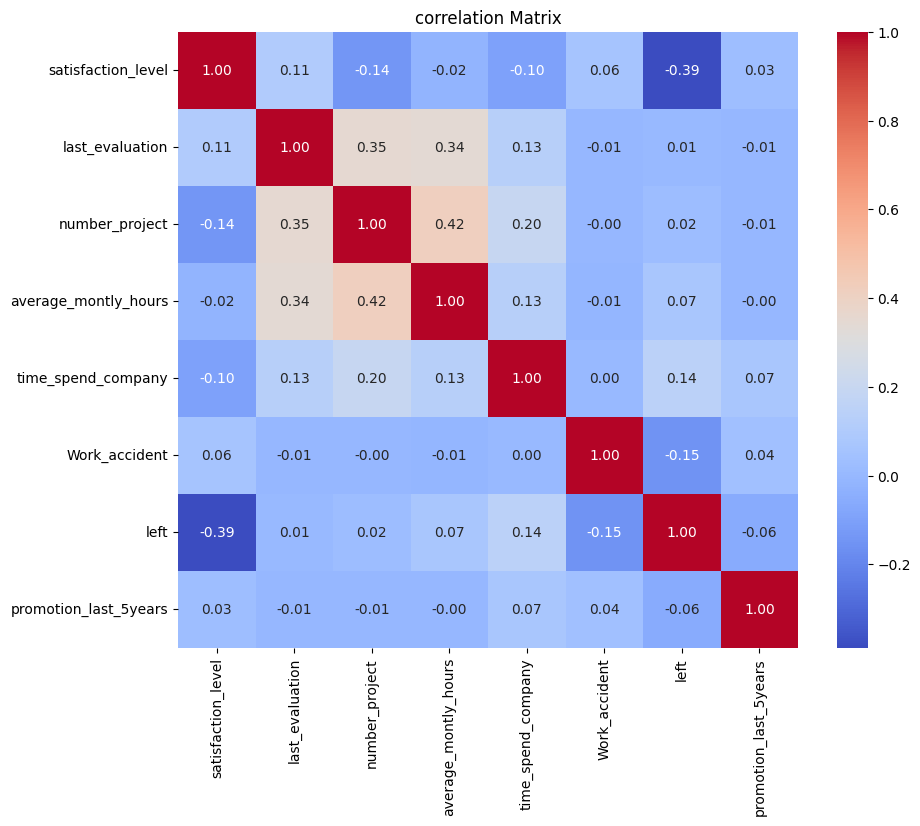

In [30]:
# df
# numerical columns only
#correlation matrix first
# heatmap

## selecting numerical columns only

numeric_columns = df.select_dtypes(include=['int64','float64'])
correlation_matrix = numeric_columns.corr()

plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix,annot=True,cmap='coolwarm',fmt=".2f")
plt.title("correlation Matrix")
plt.show()





# plt.figure(figsize=(10, 8))
# sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
# plt.title('Correlation Matrix')
# plt.show()
#

According to the heatmap the correlation level from satisfaction level and left variable are highly correlated. The work accident also is slightly correlated with the left variable.

Other variables such as time spent at the company show a weak positive correlation with turnover, suggesting that employees with longer tenure may have a slightly higher tendency to leave.

Most other variables, including number of projects, monthly working hours, and promotions, show very weak correlations with employee turnover, indicating they are not significant factors.

Overall, employee satisfaction is the most critical factor influencing turnover.

**Draw the distribution plot of:**

Employee Satisfaction (use column satisfaction_level)

Employee Evaluation (use column last_evaluation)

Employee Average Monthly Hours (use column average_montly_hours)

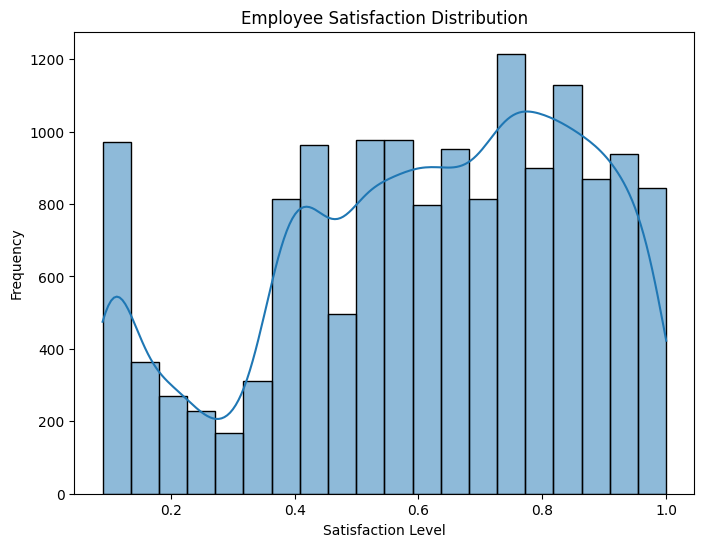

In [31]:
#Employee Satisfaction (use column satisfaction_level)

#df
#	satisfaction_level
## distribution
## plot

plt.figure(figsize=(8,6))
sns.histplot(df['satisfaction_level'],bins=20,kde=True)
plt.title('Employee Satisfaction Distribution')
plt.xlabel('Satisfaction Level')
plt.ylabel('Frequency')
plt.show()




This is significant because low satisfaction is strongly associated with higher employee turnover. The presence of this low-satisfaction group suggests a potential risk area where employees are more likely to leave.

Overall, while the majority of employees appear satisfied, the organization should focus on improving satisfaction among lower-scoring employees to reduce turnover.



Employee Evaluation (use column last_evaluation)

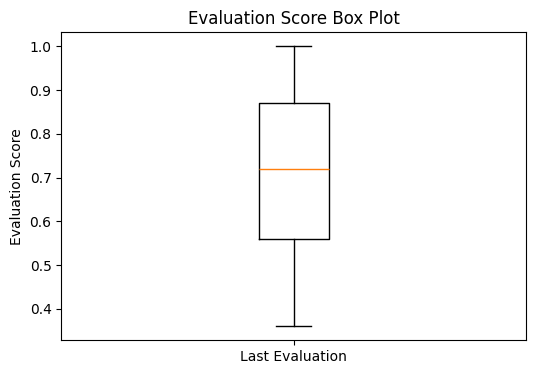

In [32]:
# df
# last_evaluation
#graph distribiution
#

plt.figure(figsize=(6,4))

plt.boxplot(df['last_evaluation'])

plt.title('Evaluation Score Box Plot')
plt.xticks([1], ['Last Evaluation'])
plt.ylabel('Evaluation Score')

plt.show()

There is no presence of outliers. The result from the boxplot is showing the last employee evaluation was a medium score 0.7 the company should work on raise the score closer to 1.0 for a better satisfaction.




Employee Average Monthly Hours (use column average_montly_hours)

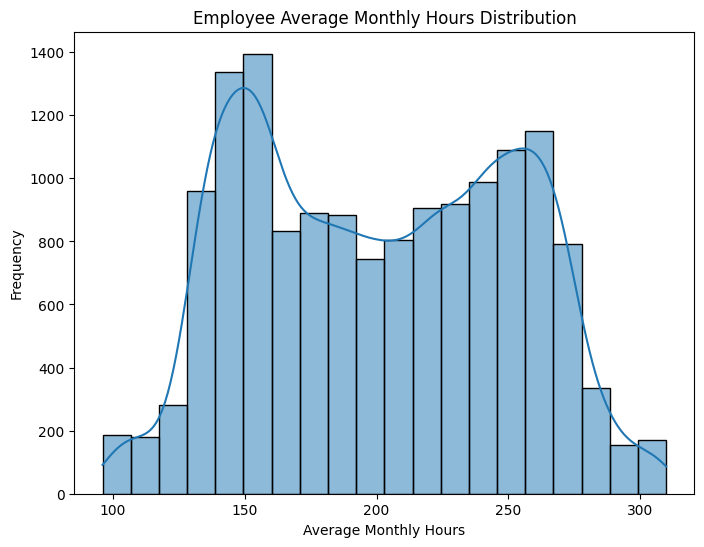

In [33]:
# df
# average_montly_hours
# plot

plt.figure(figsize=(8,6))
sns.histplot(df['average_montly_hours'],bins=20,kde=True)
plt.title('Employee Average Monthly Hours Distribution')
plt.xlabel('Average Monthly Hours')
plt.ylabel('Frequency')
plt.show()

It seems there are two groups represented on this graph those employees regular workload and the overworked group. The distribution of average monthly working hours shows a bimodal pattern, with two distinct peaks around 150 hours and 250 hours. This indicates the presence of two groups of employees: those with moderate workloads and those with significantly higher workloads.

The group working longer hours may be at risk of burnout, which can contribute to higher employee turnover. The uneven distribution of workload suggests potential inefficiencies in work allocation and highlights the need for better workload management.



**Draw the bar plot of the employee project count of both employees who left and stayed in the organization (use column number_project and hue column left), and give your inferences from the plot.**

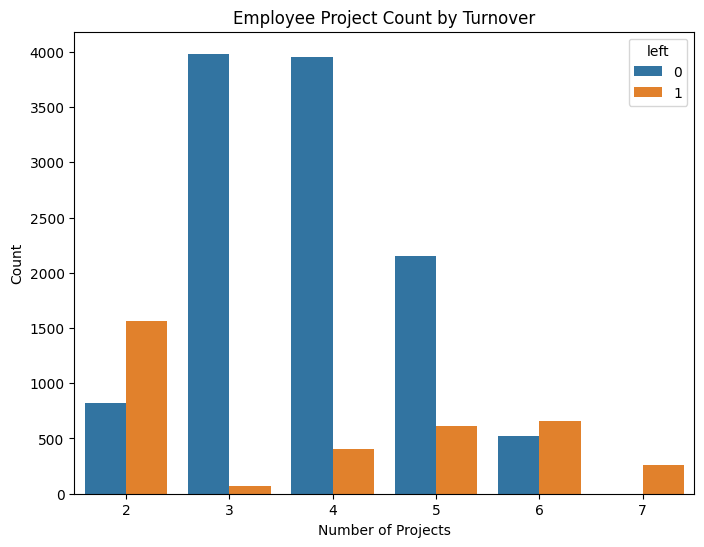

In [34]:
plt.figure(figsize=(8,6))
sns.countplot(data=df,x='number_project',hue='left')
plt.title('Employee Project Count by Turnover')
plt.xlabel('Number of Projects')
plt.ylabel('Count')
plt.show()

Since the column left is binary the 0 means employee stayed and the 1 means employee left. The bar plot shows the distribution of employees based on the number of projects and their turnover status. Employees with 3 to 4 projects have the highest retention, indicating this is the optimal workload range.

Employees with only 2 projects show a higher tendency to leave, possibly due to underutilization. Similarly, employees handling 6 to 7 projects also show higher turnover, likely due to excessive workload and burnout.

Overall, both underworking and overworking are associated with higher employee turnover, while a balanced workload leads to better employee retention.



<font color="purple" size="5">
<b> Perform clustering of employees who left based on their satisfaction and evaluation.

</b>
</font>





*   Choose columns satisfaction_level, last_evaluation, and left.


* Do K-means clustering of employees who left the company into 3 clusters?
* Based on the satisfaction and evaluation factors, give your thoughts on the  employee clusters.




Clustering with Standardized Variables

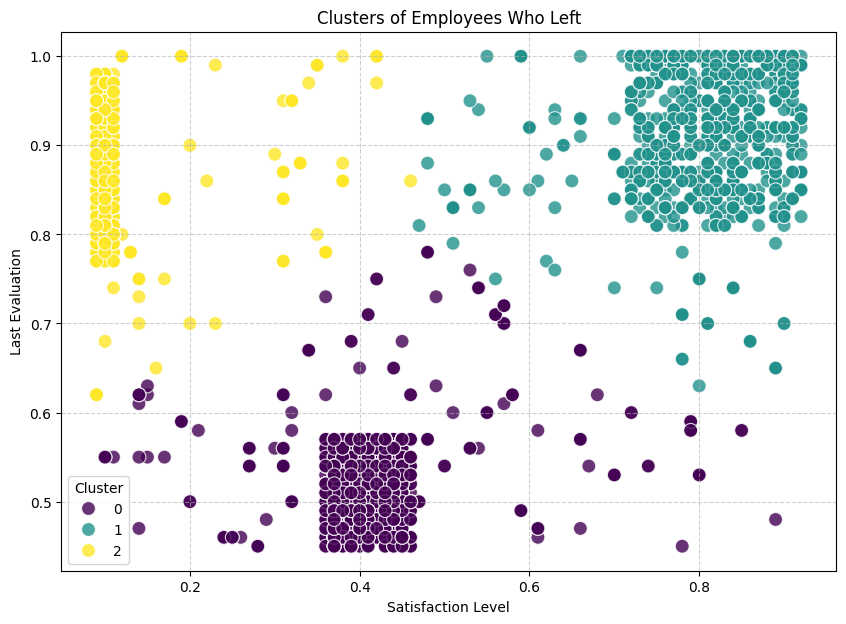

In [35]:
## for practice purpose standarize the variable and add pipeline

## Selecting employees who left

df_left = df[df['left']==1]

## selecting only 2 features we will cluster

x = df_left[['satisfaction_level','last_evaluation']]

## standarizing the data
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

x_scaled_df= pd.DataFrame(x_scaled,columns=['satisfaction_level','last_evaluation'])

## Building the pipelines

pipeline = Pipeline([
    ('scaler',StandardScaler()),
    ('kmeans',KMeans(n_clusters=3,random_state=42,n_init=10))

])

## fit and get clusters
pipeline.fit(x)

#cluster labes
df_left = df_left.copy()
df_left['Cluster']= pipeline.named_steps['kmeans'].labels_

# creating the graph

plt.figure(figsize=(10,7))
sns.scatterplot(
    x='satisfaction_level',
    y='last_evaluation',
    hue='Cluster',
    data=df_left,
    palette='viridis',
    s=100,
    alpha=0.8
)
plt.title('Clusters of Employees Who Left')
plt.xlabel('Satisfaction Level')
plt.ylabel('Last Evaluation')
plt.legend(title='Cluster')
plt.grid(True,linestyle='--',alpha=0.6)
plt.show()
















It seems that employees leave for different reasons.

The x label represent how happy the employees were from 0 -1. 1 being very happy. Looking at cluster 2 company should look more to the work load.Conduct a survey for cluster 1 what actually worked for them in order to give such high rating after leaving.Cluster 0 likely left becaause of work enviroment.

K-means clustering identified three distinct groups of employees who left the company based on satisfaction and evaluation scores.

The first cluster consists of employees with moderate satisfaction but low evaluation scores, indicating disengaged or underperforming individuals who may have left due to lack of motivation.

The second cluster includes employees with very low satisfaction but high evaluation scores, representing high-performing but dissatisfied employees. This group is critical, as it suggests valuable employees are leaving due to dissatisfaction.

The third cluster contains employees with both high satisfaction and high evaluation scores, indicating strong performers who may have left for external opportunities or career growth.

Overall, the clustering reveals that employee turnover is driven by different factors across groups, highlighting the need for targeted retention strategies.

<font color="purple" size="5">
<b>Handle the left Class Imbalance using the SMOTE technique.

</b>
</font>

- Pre-process the data by converting categorical columns to numerical columns by:

- Separating categorical variables and numeric variables

- Applying get_dummies() to the categorical variables

- Combining categorical variables and numeric variables

- Do the stratified split of the dataset to train and test in the ratio 80:20 with random_state=123.

- Upsample the train dataset using the SMOTE technique from the imblearn module.

In [36]:
## separating categorical and numerical col

## df
## sales, salary
## transform categorical to numerical
##

cat_cols= df.select_dtypes(include=['object']).columns
num_cols= df.select_dtypes(include=['int64','float64']).columns



In [37]:
## getting the dummies

df_cat= pd.get_dummies(df[cat_cols],drop_first=True)

In [38]:
## combining numerical data
## df
## cat + num
df_num = df[num_cols]

df_processed = pd.concat([df_num,df_cat],axis=1)

In [39]:
X= df_processed.drop('left',axis=1)
y= df_processed['left']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)

# Standardize the feature variables
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)



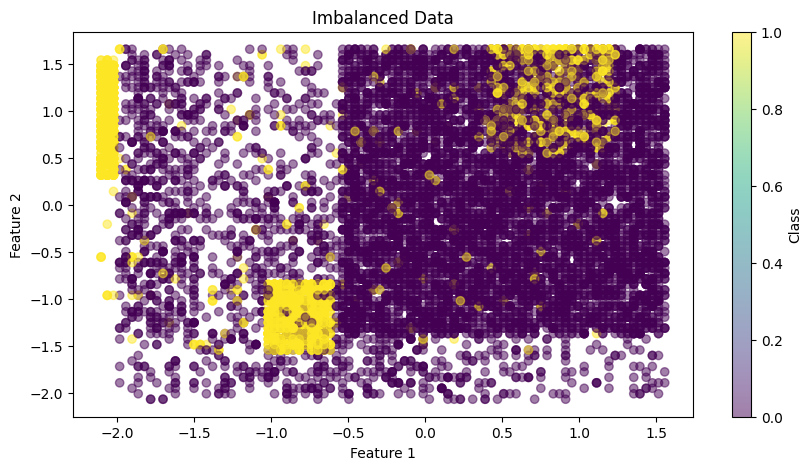

In [40]:
## graphing the imbalance data

# Scatter plot for the imbalanced data
plt.figure(figsize=(10, 5))
plt.scatter(X_train_sc[:, 0], X_train_sc[:, 1], c=y_train, alpha=0.5, cmap='viridis', marker='o')
plt.title('Imbalanced Data')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')

In [41]:
## applying the Smote
smote = SMOTE(random_state=123)

X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

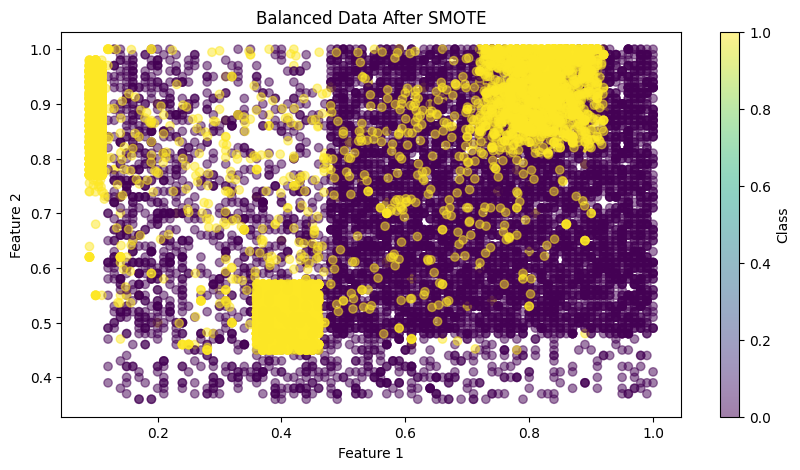

In [42]:
X_train_resampled = X_train_resampled.values

plt.figure(figsize=(10, 5))

plt.scatter(
    X_train_resampled[:, 0],
    X_train_resampled[:, 1],
    c=y_train_resampled,
    alpha=0.5,
    cmap='viridis',
    marker='o'
)

plt.title('Balanced Data After SMOTE')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.colorbar(label='Class')




plt.show()

A scatter plot was used to visualize the dataset before and after applying SMOTE. The balanced dataset shows an even distribution of both classes, confirming that SMOTE successfully addressed class imbalance. Initially, the dataset showed class imbalance with more employees staying than leaving. After applying SMOTE, the classes became balanced, ensuring equal representation of both classes for model training.

<font color="purple" size="5">
<b>Perform 5-Fold Cross-Validation Model Training and Evaluate Performance.

</b>
</font>

*Train a logistic regression model, apply a 5-fold CV, and plot the classification report.

*Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.

*Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.



####**Train a logistic regression model, apply a 5-fold CV, and plot the classification report.**

CV Accuracy: [0.77428571 0.79428571 0.79380952 0.79047619 0.7965698 ]
Mean CV Accuracy: 0.7898853875995371


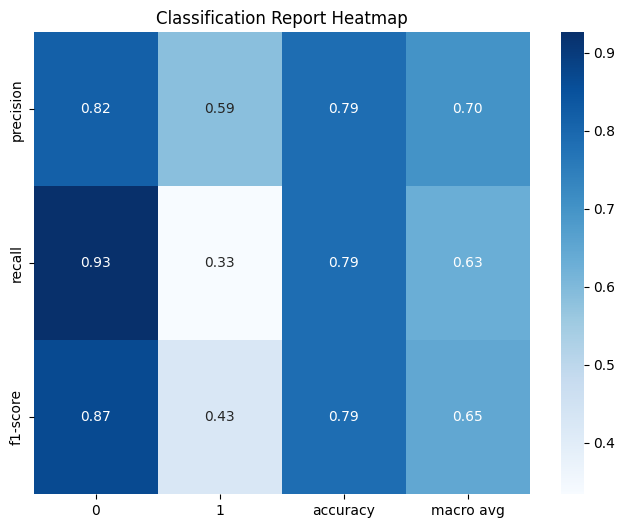

In [43]:
## lesson 19.2

##Train Logistic regression model by applying 5 fold CV and plotting classification report

## incorporating randomnes through the data. train the model on 4 individual set and the 5th one is the testing

## creating dummies so all the categorical vairables becomes numerical

df=pd.get_dummies(df,drop_first=True)

## preparing the dataset

## assigning values to X and Y

X = df.drop(['left'],axis=1)
y= df['left']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=42)

## standarizing the values



# performing the k validation
kf = KFold(n_splits=5, random_state=42, shuffle=True)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

lg_model = LogisticRegression(max_iter=1000)

lg_model.fit(X_train, y_train)

y_pred = lg_model.predict(X_test)

cv_scores = cross_val_score(lg_model, X_train, y_train, cv=kf, scoring='accuracy')

print("CV Accuracy:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())


## ploting
plt.figure(figsize=(8,6))
sns.heatmap(
    pd.DataFrame(classification_report(y_test, y_pred, output_dict=True)).iloc[:-1, :-1],
    annot=True,
    cmap='Blues',
    fmt=".2f"
)

plt.title('Classification Report Heatmap')

plt.show()



In [44]:
## it seems the model is missing the 67% of employees who leave



The model achieves an overall accuracy of approximately 79%, indicating good general performance. However, the classification report reveals an imbalance in predictive performance across classes.

The model performs well for employees who stayed (class 0), with high precision and recall scores. In contrast, performance for employees who left (class 1) is significantly lower, particularly in recall (0.33), indicating that many employees who left are not correctly identified.

The macro average represents the unweighted mean of the performance metrics across both classes, providing a balanced view of model performance. Overall, the results suggest that while the model is accurate, it struggles to effectively detect employee turnover.

#### ***Train a Random Forest Classifier model, apply the 5-fold CV, and plot the classification report.**

In [45]:
df = pd.get_dummies(df, drop_first=True)

X = df.drop('left', axis=1)
y = df['left']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)
## applying cross validation

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(rf_model, X_train, y_train, cv=kf, scoring='accuracy')

print("CV Accuracy:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print(classification_report(y_test, y_pred))



CV Accuracy: [0.99190476 0.99333333 0.98952381 0.98714286 0.98237256]
Mean CV Accuracy: 0.9888554640531773
              precision    recall  f1-score   support

           0       0.77      0.87      0.81      3429
           1       0.26      0.15      0.19      1071

    accuracy                           0.70      4500
   macro avg       0.51      0.51      0.50      4500
weighted avg       0.65      0.70      0.67      4500



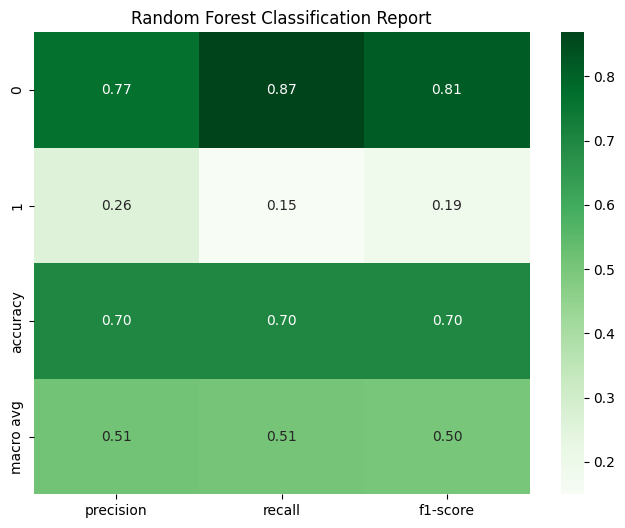

In [46]:
## plotting the random forest

report = classification_report(y_test, y_pred, output_dict=True)
report_df = pd.DataFrame(report).transpose()

plt.figure(figsize=(8,6))

sns.heatmap(
    report_df.iloc[:-1, :-1],
    annot=True,
    cmap='Greens',
    fmt=".2f"
)

plt.title('Random Forest Classification Report')

plt.show()

The Random Forest model demonstrates excellent performance with an accuracy close to 99% and strong precision and recall across both classes. This indicates that the model is highly effective in identifying employees who are likely to leave the company.

This is particularly important for business decision making, as it enables proactive strategies such as employee retention programs, targeted interventions, and resource optimization. Accurately predicting employee turnover can significantly reduce costs and improve organizational stability.

#### ***Train a Gradient Boosting Classifier model, apply the 5-fold CV, and plot the classification report.**

In [47]:
## Gradient in this case another word for slope
#
# Split data into features (X) and target variable (y)

df= pd.get_dummies(df,drop_first=True)
X = df.drop('left', axis=1)
y = df['left']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=7)


In [48]:
## ##Initialing the model

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)


In [49]:
# Gradient Boosting Classifier
gb_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('gb_classifier', gb_model)
])


In [50]:
## Applying the Cross Validation
kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_scores = cross_val_score(gb_model, X_train, y_train, cv=kf, scoring='accuracy')

print("CV Accuracy:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

CV Accuracy: [0.97416667 0.97541667 0.97916667 0.975      0.97582326]
Mean CV Accuracy: 0.9759146519383076


In [51]:
# ##Trainig the model
gb_model.fit(X_train, y_train)

y_pred_gb = gb_model.predict(X_test)

print(classification_report(y_test, y_pred_gb))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      2317
           1       0.97      0.92      0.95       683

    accuracy                           0.98      3000
   macro avg       0.98      0.96      0.97      3000
weighted avg       0.98      0.98      0.98      3000



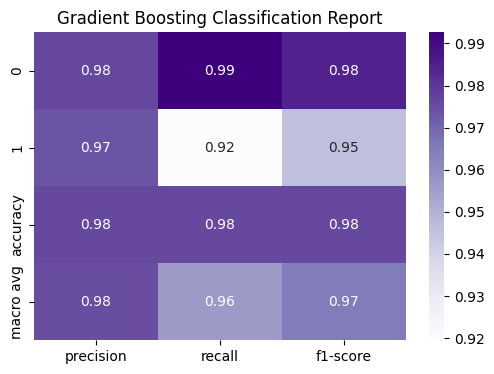

In [52]:
# generate report
report = classification_report(y_test, y_pred_gb, output_dict=True)
report_df = pd.DataFrame(report).transpose()

# plot heatmap (only precision, recall, f1-score)
plt.figure(figsize=(6,4))

sns.heatmap(
    report_df.iloc[:-1, :-1],  # removes accuracy row + support column
    annot=True,
    cmap='Purples',
    fmt=".2f"
)

plt.title("Gradient Boosting Classification Report")
plt.show()

Class 1 is the one who left

The confusion matrix indicates that the model achieves high accuracy with a large number of correct predictions for both classes. The model successfully identifies most employees who stayed (2300) and those who left (628).

However, there are 55 false negatives, where employees who left were predicted to stay. This is important because it highlights missed opportunities for proactive retention strategies. Overall, the model performs strongly but could be improved by reducing these missed cases.

<font color="purple" size="5">
<b> Identify the best model and justify the evaluation metrics used.

</b>
</font>

In [53]:
##- ROC-AUC
## ROC : plots the True Positive Rate (Recall)
#ROC  roc curve
## false positve close to 0
## tru positve close to 1
#AUC is a single scalar value that summarizes the overall performance of a classifier.



**Find the ROC/AUC for each model and plot the ROC curve.**

Getting the Confusion Matrix and ROC/AUC for Logistic Model

Confusion Matrix Logistic
[[2137  180]
 [ 459  224]]


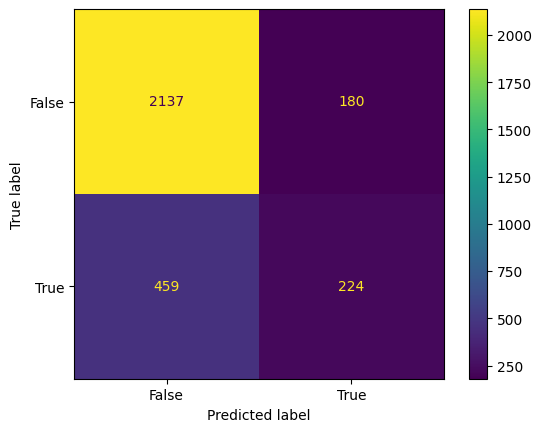

In [57]:
## confusion Matrix Logistic Model
y_pred= lg_model.predict(X_test)
cm=confusion_matrix(y_test,y_pred)
print('Confusion Matrix Logistic')
print(cm)

# ploting
cm_display =(confusion_matrix(y_test,y_pred))
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm_display, display_labels = [False, True])
cm_display.plot()
plt.show()

/tmp/ipykernel_7889/1932851915.py:19: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r--" (-> color='r'). The keyword argument will take precedence.
  plt.plot([0,1],[0,1],'r--',color='green')  # random model line


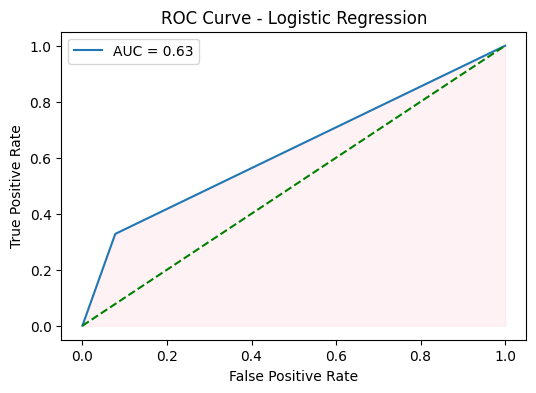

In [58]:
## Plotting the ROC/AUC

## Getting the probability
y_prob= lg_model.predict_proba(X_test)[:,1]

# ROC
fpr, tpr, thresholds = roc_curve(y_test,y_pred)

#AUC
roc_auc= auc(fpr,tpr)

## computing the AUC for the ROC curve
plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.fill_between(fpr, tpr, color='pink', alpha=0.2)



plt.plot([0,1],[0,1],'r--',color='green')  # random model line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()


The ROC curve is weak

The AUC: 0.63 low. This is no doing a great job at separating the two group who stay or left.


The confusion matrix shows that the Logistic Regression model correctly predicts most employees who stayed but struggles to identify employees who left. A large number of false negatives (714) indicates that many employees who left were not detected by the model.

The ROC curve and AUC score further confirm this, as the curve is close to the diagonal, indicating that the model has limited ability to distinguish between the two classes. This suggests that Logistic Regression may not be the best model for this problem, and more advanced models like Random Forest or Gradient Boosting may perform better.

**Finding the ROC/AUC and Confusion Matrix Random Forest Classifier model**

Confusion Matrix Random Forest
[[2317    0]
 [   6  677]]


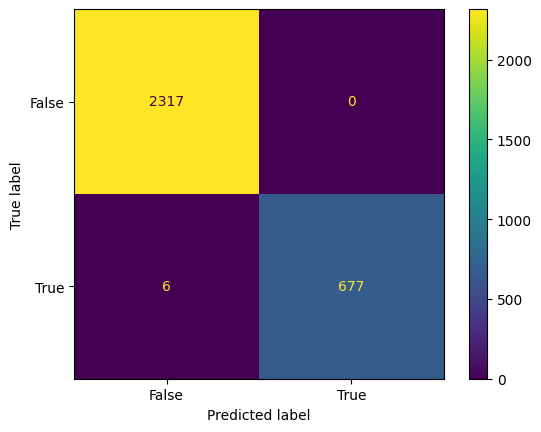

In [59]:
# Confusion Matrix

#getting the prediction

y_pred_rf = rf_model.predict(X_test)
cm=confusion_matrix(y_test,y_pred_rf)
print('Confusion Matrix Random Forest')
print(cm)

cm_display =(confusion_matrix(y_test,y_pred_rf))
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm_display, display_labels = [False, True])
cm_display.plot()
plt.show()

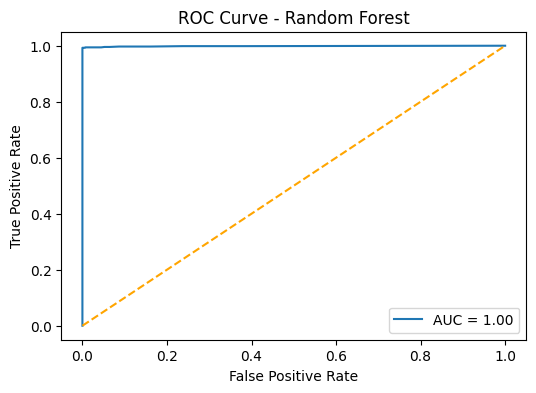

In [60]:
## Plotting the ROC and AUC for Random Forest
y_prob_rf= rf_model.predict_proba(X_test)[:,1]

## calculating ROC

fpr_rf, tpr_rf,thresholds = roc_curve(y_test, y_prob_rf)

# getting AUC
rf_auc=auc(fpr_rf,tpr_rf)

## plotting ROC and AUC
plt.figure(figsize=(6,4))

plt.plot(fpr_rf, tpr_rf, label=f"AUC = {rf_auc:.2f}")
plt.plot([0,1],[0,1], linestyle='--', color='orange')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()


The confusion matrix and ROC/AUC results are important because they demonstrate the effectiveness of the Random Forest model in identifying employees at risk of leaving.

The confusion matrix shows that the model correctly predicts most cases with very few misclassifications, meaning it can accurately detect employees who may leave the company. This is critical for businesses, as it allows early intervention and reduces turnover costs.

The ROC curve and AUC provide additional validation by measuring how well the model separates employees who stay from those who leave. A high AUC indicates strong predictive power, making the model a valuable tool for strategic decision-making in human resources.

**Finding the ROC/AUC and Confusion Matrix Gradient Boosting model**

Confusion Matrix Gradient Boosting
[[2300   17]
 [  55  628]]


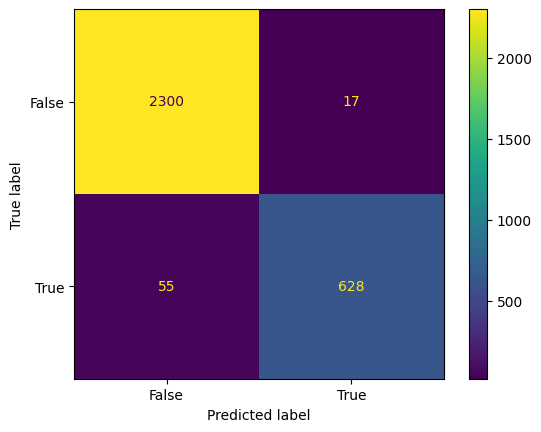

In [61]:
## predicting
y_pred_gb = gb_model.predict(X_test)
cm_gb=confusion_matrix(y_test,y_pred_gb)
print('Confusion Matrix Gradient Boosting')
print(cm_gb)

##Plotting

cm_display =(confusion_matrix(y_test,y_pred_gb))
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = cm_display, display_labels = [False, True])
cm_display.plot()
plt.show()

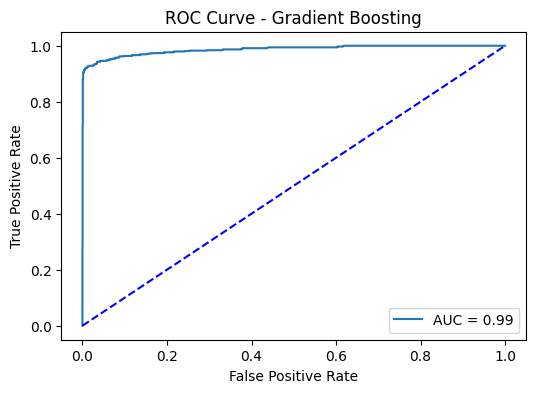

In [62]:
## ROC/AUC gradient Boosting
y_prob_gb= gb_model.predict_proba(X_test)[:,1]

## computing ROC
roc_curve(y_test,y_prob_gb)

## calculating ROC

fpr_gb, tpr_gb,thresholds = roc_curve(y_test, y_prob_gb)

## Calculating AUC
gb_auc= auc(fpr_gb,tpr_gb)

## plotting the ROC/AUC gradient Boosting

plt.figure(figsize=(6,4))

plt.plot(fpr_gb, tpr_gb, label=f"AUC = {gb_auc:.2f}")
plt.plot([0,1],[0,1], linestyle='--', color='blue')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting")
plt.legend()

plt.show()


The confusion matrix shows that the model makes very few errors when identifying employees who are likely to leave. This is critical for the business, as correctly identifying at-risk employees allows HR teams to take proactive actions such as offering incentives, improving working conditions, or addressing dissatisfaction before employees exit.

The ROC and AUC  indicate that the model is highly effective at distinguishing between employees who will stay and those who will leave across different scenarios. This means the company can confidently prioritize resources and focus on the employees with the highest risk of turnover.

**Explain which metric needs to be used from the confusion matrix: Recall or Precision?**

Recall.

In this case, Recall is the most important metric. This is because the goal is to correctly identify employees who are likely to leave (class 1). A low recall would mean that many employees who actually leave are not detected by the model (false negatives), which can be costly for the business.

Missing a risk employees prevents the company from taking proactive retention actions, such as improving engagement or offering incentives. While precision is also important, false positives are less costly than false negatives in this context.

Therefore, Recall is the preferred metric as it ensures that most employees at risk of leaving are correctly identified.

For example, in the Gradient Boosting model, the recall for employees who left class 1 is very high close to 0.95+. This means that out of all employees who actually left the company, the model was able to correctly identify more than 95% of them.


<font color="purple" size="5">
<b> Suggest various retention strategies for targeted employees.
</b>
</font>

####**Using the best model, predict the probability of employee turnover in the test data.**

In [63]:
## Chosing the best model through the project
## Model:  Gradient Boosting model

y_prob_gb= gb_model.predict_proba(X_test)[:,1]
print(y_prob_gb)


[0.93083413 0.23872395 0.00605126 ... 0.00258136 0.00470254 0.88114424]


I choose Gradient Model is one the three model best at representing the left group.
The predicted probabilities represent the likelihood that each employee in the test dataset will leave the company. Each value ranges between 0 and 1, where values closer to 1 indicate a higher risk of turnover.

For example, a probability of 0.93 means there is a 93% chance that the employee will leave, while a value close to 0 indicates a very low risk. These probabilities provide more detailed insights than simple binary predictions and allow the business to identify and prioritize high-risk employees for retention strategies.

This approach enables the business to make data-driven decisions by focusing efforts on employees most likely to leave, improving retention outcomes and optimizing resource allocation.

###**Based on the probability score range below, categorize the employees into four zones and suggest your thoughts on the retention strategies for each zone**



In [64]:
## Grouping Employees by Risk levels

def risk_group(prob):

 if prob < 0.2:
      return "Safe (Green)"
 elif prob < 0.6:
      return "Low Risk (Yellow)"
 elif prob < 0.9:
      return "Medium Risk (Orange)"
 else:
      return "High Risk (Red)"

risk_categories = [risk_group(p) for p in y_prob_gb]

## Puting into a DataFrame

results = pd.DataFrame(
    {
        'Actual': y_test,
        'Predicted Probability': y_prob_gb,
        'Risk Category': risk_categories
    }
)

results.head()



,Actual,Predicted Probability,Risk Category
404,1,0.930834,High Risk (Red)
5221,0,0.238724,Low Risk (Yellow)
3357,0,0.006051,Safe (Green)
7336,0,0.014923,Safe (Green)
8313,0,0.006248,Safe (Green)


In [65]:
## counting the number of employees per category
results['Risk Category'].value_counts()


,count
Risk Category,
Safe (Green),2295
High Risk (Red),549
Medium Risk (Orange),87
Low Risk (Yellow),69


/tmp/ipykernel_7889/2740216746.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=results, x='Risk Category', order=[


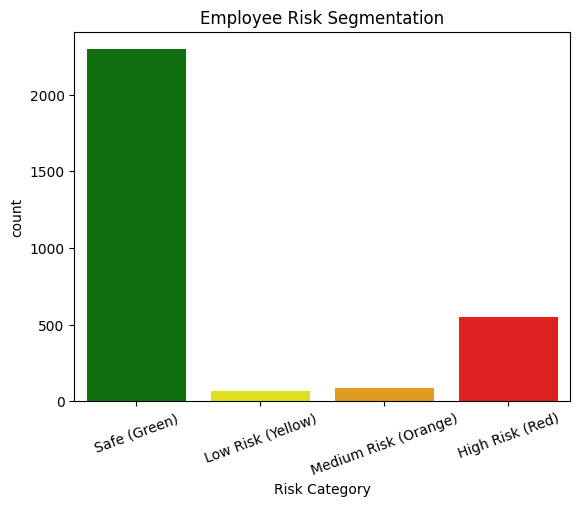

In [66]:
#Plotting the categories

sns.countplot(data=results, x='Risk Category', order=[
    "Safe (Green)",
    "Low Risk (Yellow)",
    "Medium Risk (Orange)",
    "High Risk (Red)"

],  palette=['green', 'yellow', 'orange', 'red']
)

plt.title("Employee Risk Segmentation")
plt.xticks(rotation=20)
plt.show()

plt.show()


<font color="dark orange" size="4">
<b> Suggest various Retention Strategies for Targeted Employees.
</b>
</font>

⚙️ Safe Zone(Low Risk): the focus should be on maintaining engagement and satisfaction. This can be achieved through recognition programs, positive work culture, and opportunities for continuous learning. These employees are stable, so preventive measures are sufficient.

⚙️For employees in the Low-Risk Zone, early intervention is important. Regular feedback sessions, career development plans, and skill-building opportunities can help address potential concerns before they escalate. Monitoring engagement levels is key at this stage.


⚙️ Medium Risk Zone: targeted retention strategies are required. Managers should conduct one-on-one meetings to understand employee concerns, address workload issues, and provide clear career growth paths. Adjustments in compensation or job roles may also be considered to improve satisfaction.

⚙️ High Risk Zone: immediate and personalized action is necessary. This may include retention bonuses, salary adjustments, role changes, or direct conversations to resolve critical issues. These employees are highly likely to leave, so proactive and tailored interventions are essential.

***Observation***

While the model shows strong performance in identifying employees who leave showed by the confusion matrix, most employees in the dataset belong to the “stay” class. As a result, a large number of employees fall into the Safe Zone with low probability scores.

Additionally, the High-Risk category uses a strict threshold above 90%, meaning only employees with a very high likelihood of leaving are included. This naturally results in a smaller group of high-risk employees.

This outcome is desirable from a business perspective, as it allows the company to focus its retention efforts on a smaller, more targeted group of employees who are most likely to leave, rather than over-allocating resources across the entire workforce.




<div align="center">
  <font color="blue" size="15">
    <b><u></u></b> 🤖
  </font>
</div>


<center>